### 1.4.7.1. Power Series Solutions About Ordinary Points

$$
y = \sum_{n=0}^{\infty} c_n x^{n}
\;\xrightarrow{\text{substitute}}\;
\text{recurrence relation for } c_{n} \;\Rightarrow\; y = c_0\,y_1(x) + c_1\,y_2(x) .
$$

**Explanation:**

When a linear equation has variable coefficients with no elementary closed-form solution, it can still be solved as a [power series](../../03_Calculus/04_Sequences_Series_and_Taylor_Approximation/03_power_series.ipynb) about an **ordinary point** (a point where the normalized coefficients are analytic). Substituting $y = \sum c_n x^n$ and matching powers of $x$ produces a **recurrence relation** that generates the coefficients from two free constants $c_0, c_1$ — giving the two independent solutions $y_1, y_2$. The series is guaranteed to converge at least up to the nearest singular point. This is the same [Taylor-series](../../03_Calculus/04_Sequences_Series_and_Taylor_Approximation/04_taylor_and_maclaurin_series.ipynb) idea used to approximate special-function solutions and locally model nonlinear dynamics.

**Properties:**
- At an ordinary point, two linearly independent power-series solutions always exist (Theorem 6.2.1).
- $c_0 = y(0)$ and $c_1 = y'(0)$, so the two constants are exactly the initial data.

**Numerical Example:**

Solve **Airy's equation** $y'' - xy = 0$ (ordinary point at $0$).

**Substitute** $y = \sum_{n=0}^{\infty} c_n x^n$, so $y'' = \sum_{n=2}^{\infty} n(n-1)c_n x^{n-2}$. Then

$$
y'' - xy = \sum_{n=2}^{\infty} n(n-1)c_n x^{n-2} - \sum_{n=0}^{\infty} c_n x^{n+1} = 0 .
$$

**Shift indices** to a common power $x^k$:

$$
2c_2 + \sum_{k=1}^{\infty}\big[(k+1)(k+2)c_{k+2} - c_{k-1}\big]x^k = 0 .
$$

**Match coefficients:** $2c_2 = 0 \Rightarrow c_2 = 0$, and the recurrence

$$
c_{k+2} = \frac{c_{k-1}}{(k+1)(k+2)}, \qquad k = 1, 2, 3, \ldots
$$

**Generate coefficients:** $c_3 = \tfrac{c_0}{6}$, $c_4 = \tfrac{c_1}{12}$, $c_5 = 0$, $c_6 = \tfrac{c_0}{180}$, … Collecting the $c_0$ and $c_1$ parts gives $y = c_0 y_1 + c_1 y_2$ with

$$
y_1 = 1 + \frac{x^3}{6} + \frac{x^6}{180} + \cdots, \qquad
y_2 = x + \frac{x^4}{12} + \frac{x^7}{504} + \cdots,
$$

both convergent for all $x$.

In [1]:
import sympy as sp

x = sp.symbols("x")
y = sp.Function("y")

order = 9
coefficients = sp.symbols(f"c0:{order}")
trial_series = sum(coefficients[n] * x**n for n in range(order))
residual = sp.expand(trial_series.diff(x, 2) - x * trial_series)
equations = [residual.coeff(x, power) for power in range(order - 2)]
solved = sp.solve(equations, coefficients[2:], dict=True)[0]

power_series = sp.dsolve(sp.Eq(y(x).diff(x, 2) - x * y(x), 0), y(x), hint="2nd_power_series_ordinary", n=8)

print("recurrence c_{k+2} = c_{k-1}/((k+1)(k+2)); from it:")
for name in coefficients[2:7]:
    print(f"  {name} =", solved[name])
print("dsolve power series:", power_series.rhs)

recurrence c_{k+2} = c_{k-1}/((k+1)(k+2)); from it:
  c2 = 0
  c3 = c0/6
  c4 = c1/12
  c5 = 0
  c6 = c0/180
dsolve power series: C2*(x**6/180 + x**3/6 + 1) + C1*x*(x**6/504 + x**3/12 + 1) + O(x**8)


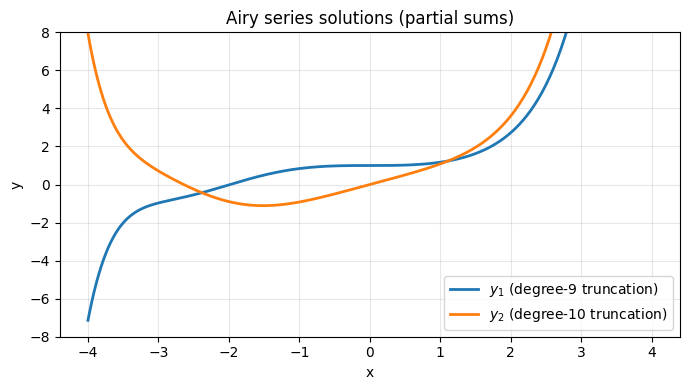

In [2]:
import numpy as np
import matplotlib.pyplot as plt

grid = np.linspace(-4, 4, 300)
y_1 = 1 + grid**3 / 6 + grid**6 / 180 + grid**9 / (2 * 3 * 5 * 6 * 8 * 9)
y_2 = grid + grid**4 / 12 + grid**7 / 504 + grid**10 / (3 * 4 * 6 * 7 * 9 * 10)

plt.figure(figsize=(7, 4))
plt.plot(grid, y_1, linewidth=2, label=r"$y_1$ (degree-9 truncation)")
plt.plot(grid, y_2, linewidth=2, label=r"$y_2$ (degree-10 truncation)")
plt.xlabel("x"); plt.ylabel("y"); plt.title("Airy series solutions (partial sums)")
plt.ylim(-8, 8); plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
plt.show()

**References:**

[📘 Zill, D. G. (2016). *A First Course in Differential Equations with Modeling Applications* (11th ed.). Cengage Learning.](https://www.cengage.com/c/a-first-course-in-differential-equations-with-modeling-applications-11e-zill/9781305965720/)

---

[⬅️ Previous: Dirac Delta and Transfer Functions](../06_Laplace_Transforms/06_dirac_delta_and_transfer_functions.ipynb) | [Next: Method of Frobenius ➡️](./02_method_of_frobenius.ipynb)